In [1]:
import pandas as pd
from noema.params import DATA_PATH
import seaborn as sns
from noema.params import DATA_PATH
data = pd.read_csv(f'{DATA_PATH}/noema_data.csv')
data['time']= pd.to_datetime(data['time'], yearfirst=True)
data.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/janduplessis/code/janduplessis883/packages/project-noema/noema/data/noema_data.csv'

In [7]:
# !pip install ruptures

In [8]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(30,10))
# sns.swarmplot(data=data, x='time', y='richness_score', hue='actionability')
# plt.show()

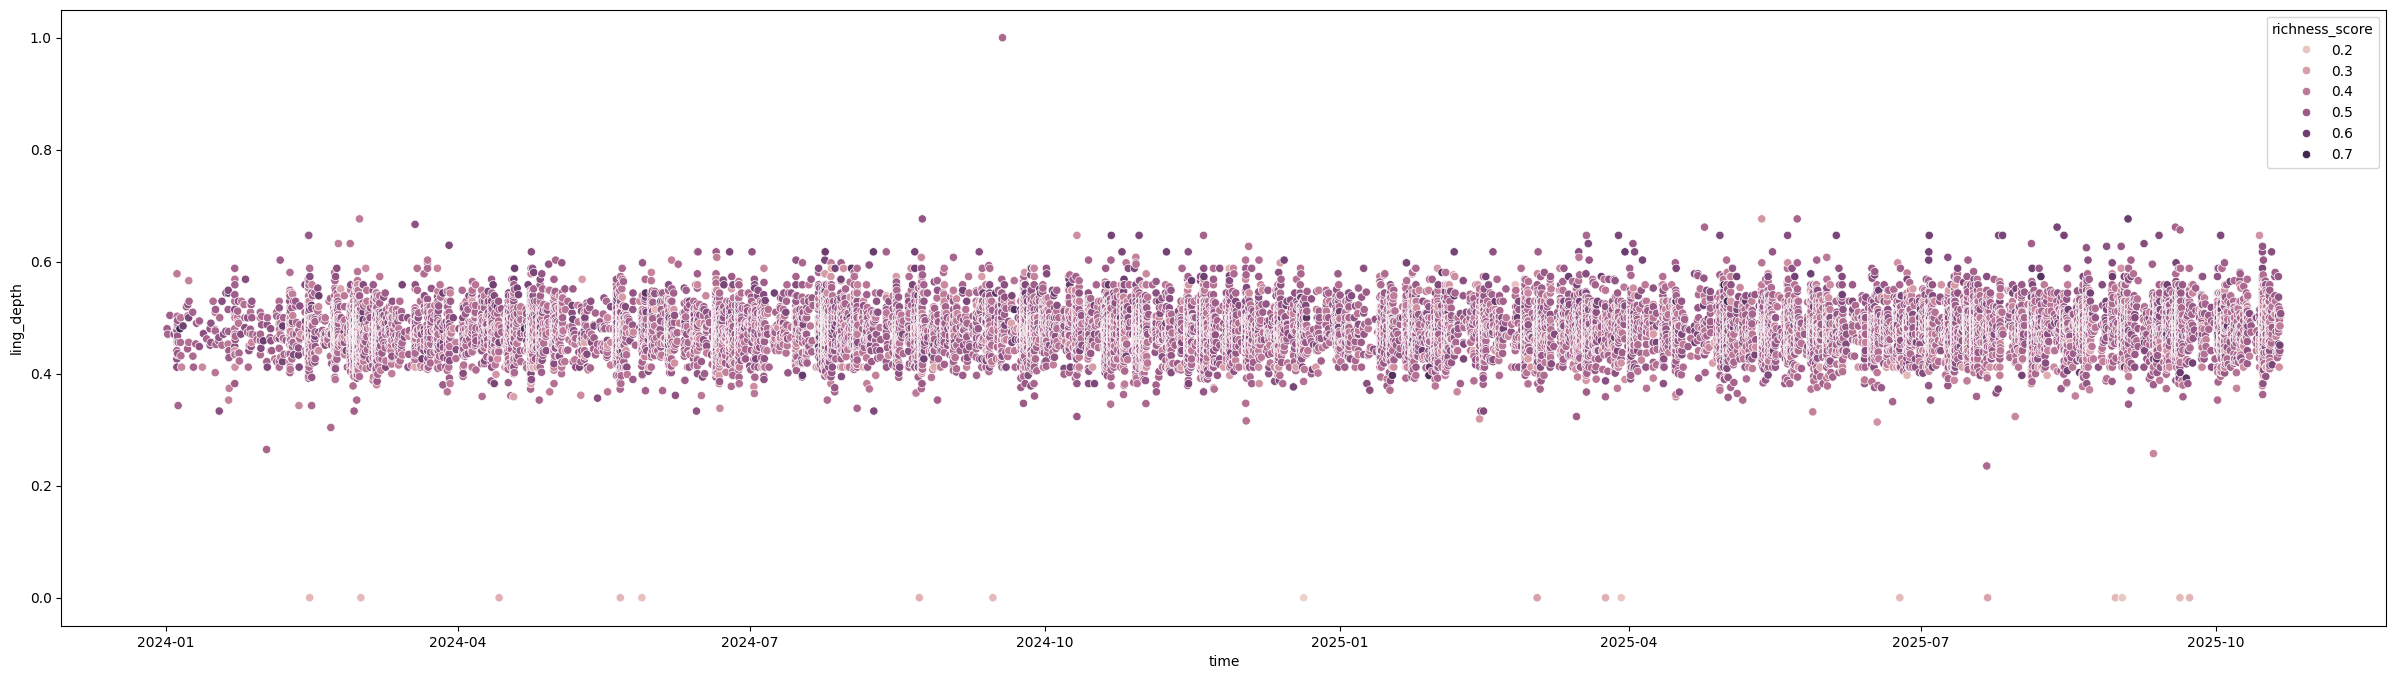

In [9]:
plt.figure(figsize=(30,8))
sns.scatterplot(data=data, x='time', y='ling_depth', hue='richness_score')
plt.show()

In [10]:
# plt.figure(figsize=(30,8))
# sns.stripplot(data=data, x='time', y='actionability', hue='richness_score')
# plt.show()

In [11]:
# plt.figure(figsize=(30,8))
# sns.swarmplot(data=data, x='time', y='semantic_density', hue='richness_score')
# plt.show()

In [12]:
# plt.figure(figsize=(30,8))
# sns.swarmplot(data=data, x='time', y='sem_dispersion', hue='richness_score')
# plt.show()

<Axes: xlabel='ling_depth', ylabel='Count'>

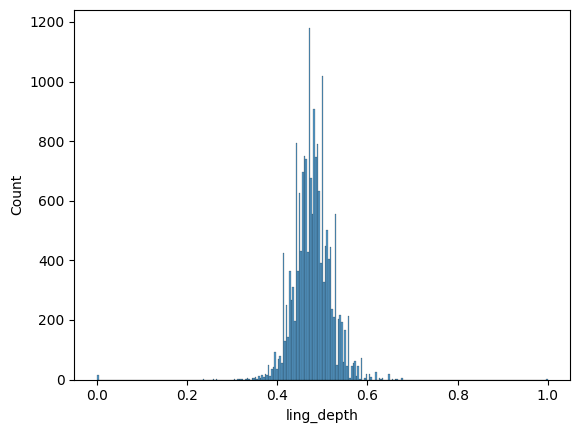

In [13]:
sns.histplot(data['ling_depth'])

<Axes: xlabel='sem_dispersion', ylabel='Count'>

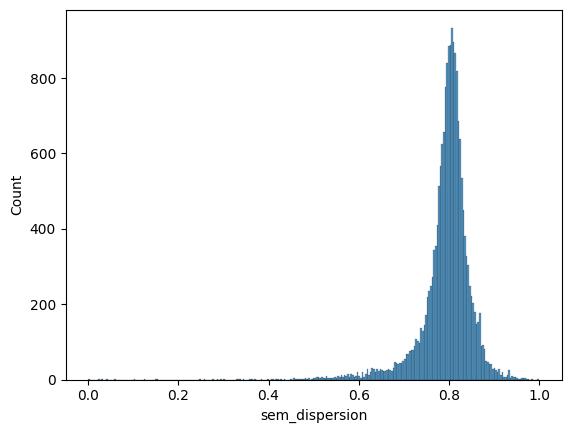

In [14]:
sns.histplot(data['sem_dispersion'])

<Axes: xlabel='semantic_density', ylabel='Count'>

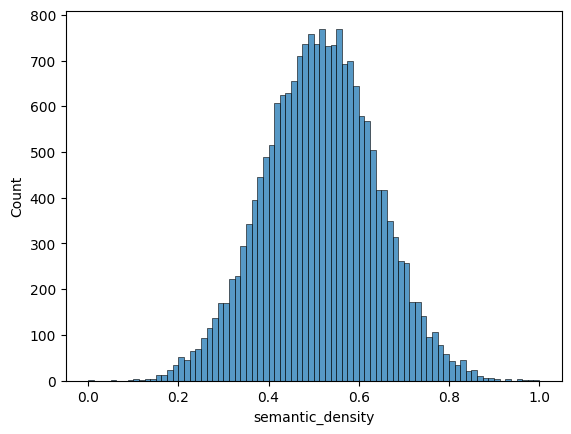

In [15]:
sns.histplot(data['semantic_density'])

<Axes: xlabel='actionability', ylabel='Count'>

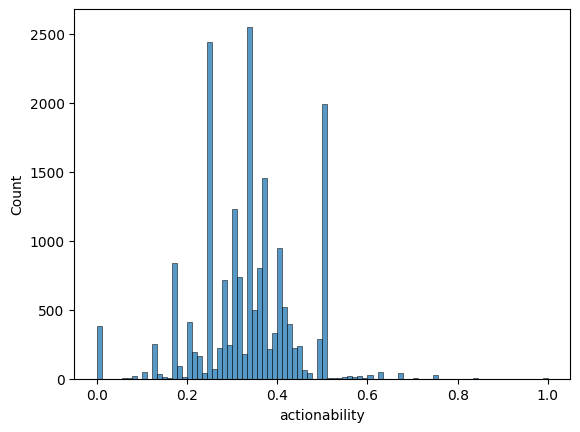

In [16]:
sns.histplot(data['actionability'])

<Axes: xlabel='richness_score', ylabel='Count'>

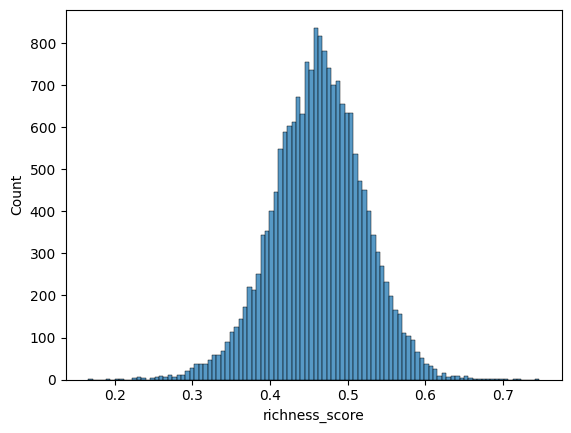

In [17]:
sns.histplot(data['richness_score'])

In [18]:
data.isna().sum()

time                 0
review               0
pcn                  4
surgery              4
origin               0
review_word_count    0
ling_depth           0
sem_dispersion       0
semantic_density     0
actionability        0
richness_score       0
embedding            0
dtype: int64

In [19]:
data.dropna(subset=['richness_score'], inplace=True)

In [20]:
from noema.params import MODEL_PATH
from gensim.models import Word2Vec
model = Word2Vec.load(f"{MODEL_PATH}/word2vec_model.model")

from noema.data import semantic_dispersion_calculator

In [21]:
text1 = "Thank you very much doctor"

In [22]:
text2 = """Dr acted immediately on my behalf Called on Monday and got my operation date by Thursday for 23 10 25 Surgery also notified me of direction of blood thinners two days before operation Impressed Hope I ll get that service for my toe operation after the wrist operation As the orthopaedic team have not given me a date yet after operation was ca cancelled operation ybecause the ECG monitor was booked for after the operation and needed to be done before so pre operation assessment and haven t had results or rebooking date Surgery I m absolutely happy with 🙏🏼carol barac"""

In [23]:
semantic_dispersion_calculator(text1, model)

np.float32(1.0280483)

In [24]:
semantic_dispersion_calculator(text2, model)

np.float32(0.9375027)

In [25]:
day = data.resample("D", on='time')['ling_depth','sem_dispersion','actionability','richness_score'].mean()
day.reset_index(inplace=True)

In [26]:
day.head()

,time,ling_depth,sem_dispersion,actionability,richness_score
0,2024-01-01,0.475490,0.752507,0.375000,0.467482
1,2024-01-02,0.504202,0.780657,0.321429,0.483088
2,2024-01-03,0.470588,0.876154,0.500000,0.515381
3,2024-01-04,0.464325,0.778237,0.358018,0.472048
4,2024-01-05,0.456033,0.836614,0.384615,0.471430


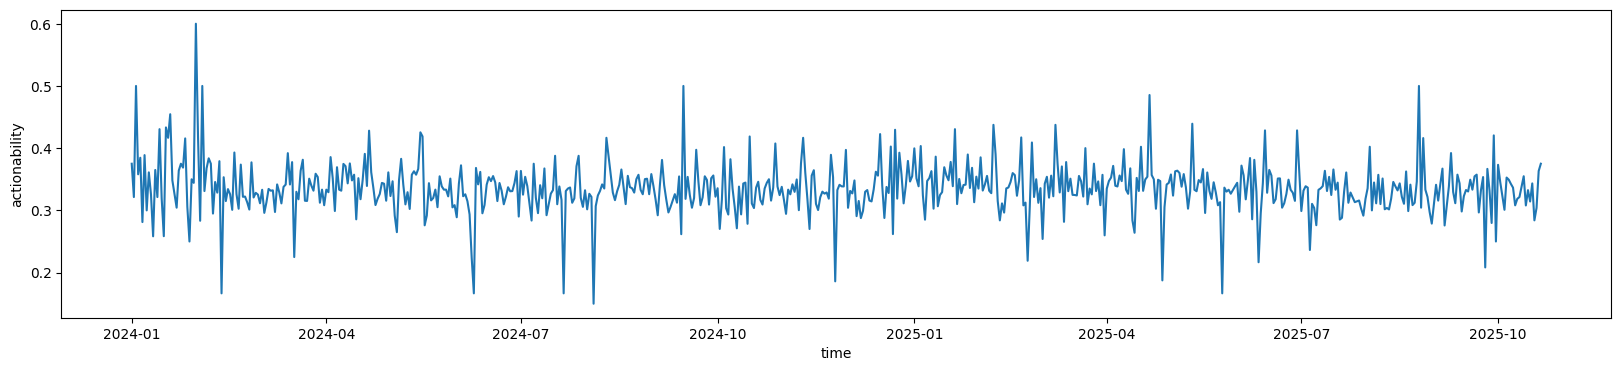

In [27]:
plt.figure(figsize=(20,4))
sns.lineplot(data=day, x='time', y='actionability')
plt.show()

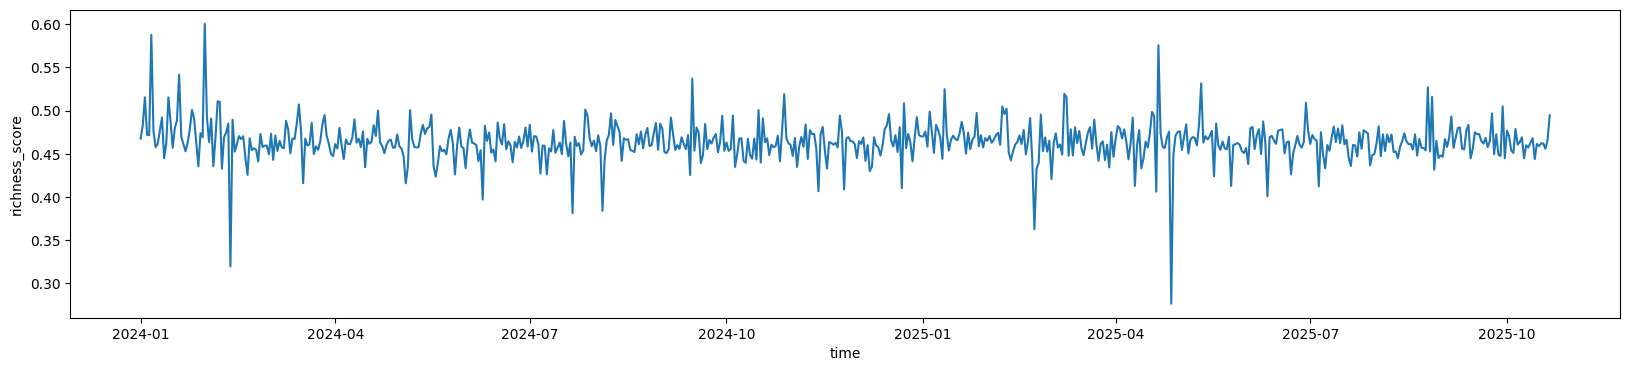

In [28]:
plt.figure(figsize=(20,4))
sns.lineplot(data=day, x='time', y='richness_score')
plt.show()

In [53]:
week = data.resample("W", on='time')['ling_depth','sem_dispersion','actionability','richness_score'].sum()
week.reset_index(inplace=True)

In [54]:
week.head()

,time,ling_depth,sem_dispersion,actionability,richness_score
0,2024-01-07,17.361474,29.297555,13.565586,17.643425
1,2024-01-14,8.517388,14.475586,5.922275,8.484727
2,2024-01-21,13.130841,22.434814,10.007633,13.432040
3,2024-01-28,27.064845,43.820974,18.616646,25.993171
4,2024-02-04,12.352075,22.135510,9.780657,12.756049


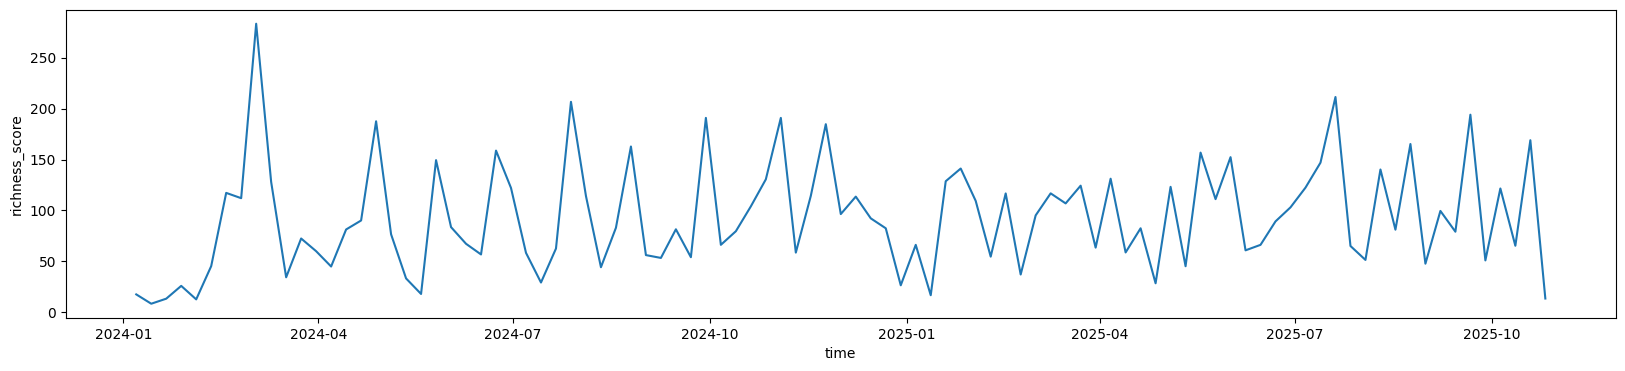

In [55]:
plt.figure(figsize=(20,4))

sns.lineplot(data=week, x='time', y='richness_score')
plt.show()

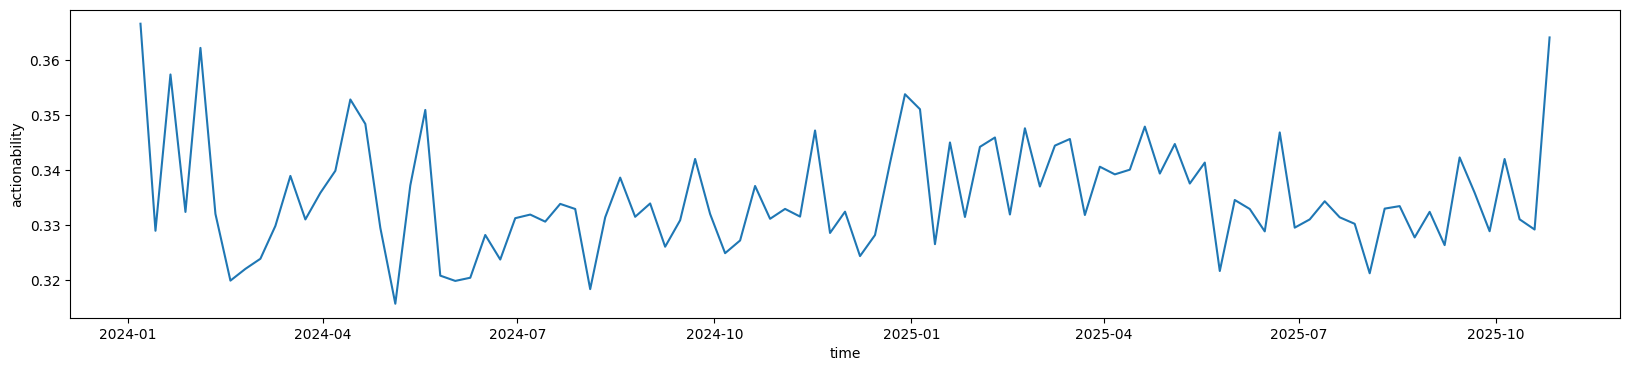

In [32]:
plt.figure(figsize=(20,4))

sns.lineplot(data=week, x='time', y='actionability')
plt.show()

In [33]:
month = data.resample("M", on='time')['ling_depth','sem_dispersion','actionability','richness_score'].mean()
month.reset_index(inplace=True)

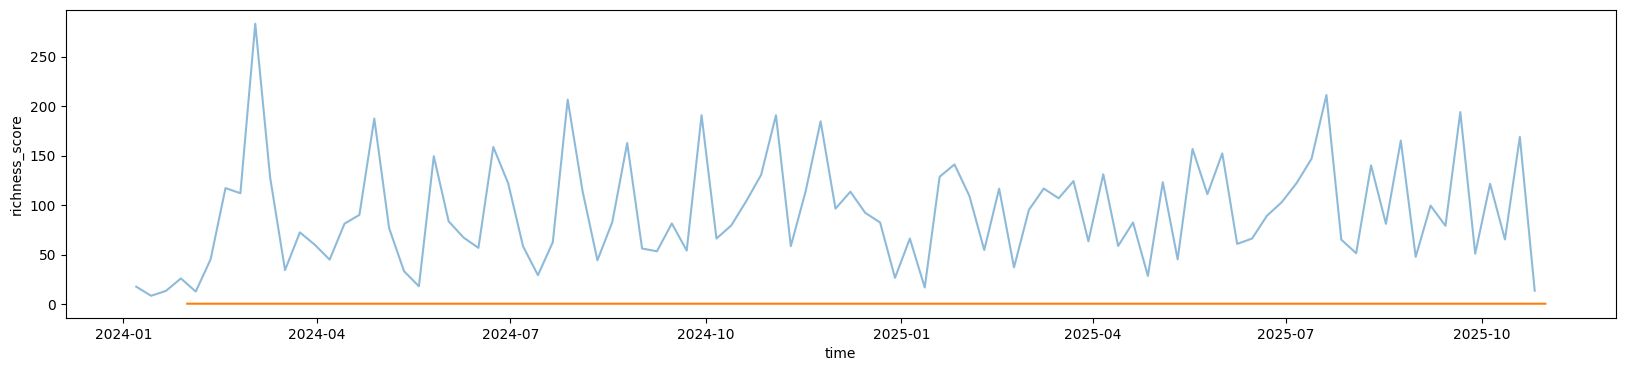

In [60]:
plt.figure(figsize=(20,4))

sns.lineplot(data=week, x='time', y='richness_score',alpha=0.5)
sns.lineplot(data=month, x='time', y='richness_score')
plt.show()

Changepoints detected at indices: Richness Score of FFT Feedback


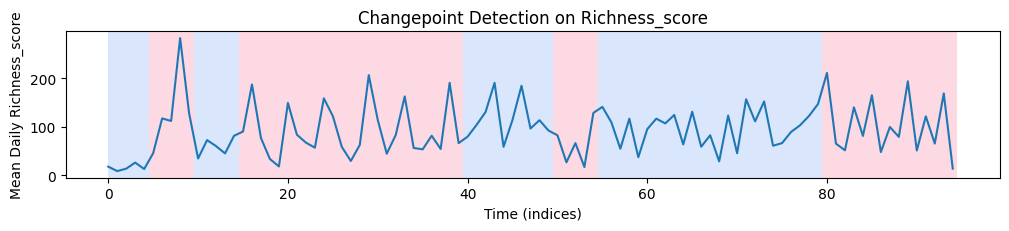

In [59]:
import ruptures as rpt

# Create a Pelt changepoint detection model
model = "rbf" # You can choose other models like 'l2', 'rbf', 'linear', etc.
algo = rpt.Pelt(model=model).fit(week['richness_score'].values)

# Find changepoints
result = algo.predict(pen=0.3) # You might need to adjust the 'pen' value based on your data

# Print the changepoints
print(f"Changepoints detected at indices: Richness Score of FFT Feedback")

# You can also visualize the changepoints
rpt.display(week['richness_score'].values, result)
plt.title(f"Changepoint Detection on Richness_score")
plt.xlabel("Time (indices)")
plt.ylabel("Mean Daily Richness_score")
plt.show()

Changepoints detected at indices: Richness Score of FFT Feedback


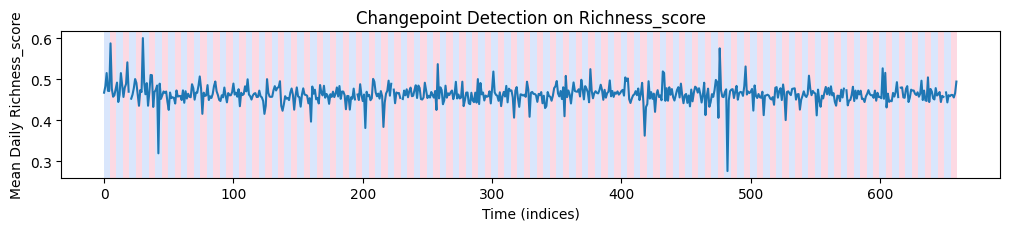

In [52]:
import ruptures as rpt

# Create a Pelt changepoint detection model
model = "rbf" # You can choose other models like 'l2', 'rbf', 'linear', etc.
algo = rpt.Pelt(model=model).fit(day['richness_score'].values)

# Find changepoints
result = algo.predict(pen=20) # You might need to adjust the 'pen' value based on your data

# Print the changepoints
print(f"Changepoints detected at indices: Richness Score of FFT Feedback")

# You can also visualize the changepoints
rpt.display(day['richness_score'].values, result)
plt.title(f"Changepoint Detection on Richness_score")
plt.xlabel("Time (indices)")
plt.ylabel("Mean Daily Richness_score")
plt.show()

In [61]:
df = pd.read_csv('/Users/janduplessis/code/janduplessis883/packages/project-noema/noema/data/noema_data_scored.csv')
df.head()

,time,review,pcn,surgery,origin,review_word_count,embedding,ling_depth,sem_dispersion,actionability,richness_score,llm_richness_score
0,2024-01-01 10:51:00,Everyone kind and helpful,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,NaN,0.480392,0.706032,0.500000,0.566229,1.0
1,2024-01-01 15:20:00,Nothing. It was all great,Brompton-Health-PCN,Brompton-Health-PCN,feedback,5.0,NaN,0.470588,0.798982,0.250000,0.508320,1.0
2,2024-01-02 07:58:00,"Denise was amazing, kind and helpful. The rece...",Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,23.0,NaN,0.504202,0.780657,0.321429,0.536991,4.0
3,2024-01-03 15:19:00,No issues with me,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,4.0,NaN,0.470588,0.876154,0.500000,0.622830,1.0
4,2024-01-04 10:42:00,We have had Very good service from the NHS reg...,Brompton-Health-PCN,Scarsdale-Medical-Centre,feedback,22.0,NaN,0.455882,0.818985,0.375000,0.554659,2.0


<Axes: xlabel='llm_richness_score', ylabel='Count'>

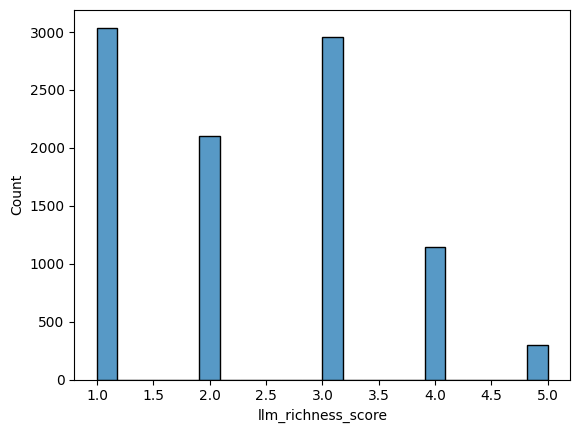

In [62]:
sns.histplot(df['llm_richness_score'])